# NeRF from COLMAP Reconstruction

Train a **NeRF** neural radiance field directly from the camera poses and sparse point cloud produced by the **previously ran COLMAP SfM pipeline**.

### Pipeline overview
1. **Load** COLMAP binary model (`cameras.bin`, `images.bin`, `points3D.bin`)
2. **Build dataset** – load images, compute camera-to-world matrices, normalise scene, pre-compute rays
3. **Train** – coarse NeRF + optional hierarchical fine network
4. **Render** – synthesise novel views and a depth map
5. **Save** – write rendered images to disk

## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

# Make the utils/ folder importable
REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "utils"))
    
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange
from torchinfo import summary
import time
import imageio

from nerf import (
    NeRF,
    InstantNGP,
    get_instant_ngp,
    get_fast_nerf,
    ColmapNeRFDataset,
    pose_spherical,
    render_rays,
    run_network,
    get_rays,
    get_embedder,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Configuration

Set paths and hyper-parameters here. Adjust `SCALE_FACTOR` to trade image
resolution for training speed (0.25 → 4× faster, 0.5 → 2× faster).
Use `MODEL = "tiny"` for a quick sanity-check or `MODEL = "fast"` for
the full factored FastNeRF model.

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Change these to point at a different COLMAP reconstruction / image folder.
COLMAP_DIR = str(REPO_ROOT / "results" / "colmap_miniature" / "0")
IMAGE_DIR  = str(REPO_ROOT / "data" / "images" / "miniature")
OUTPUT_DIR = str(REPO_ROOT / "results" / "nerf_miniature")

# ── Image scale ───────────────────────────────────────────────────────────────
SCALE_FACTOR = 0.25          # resize images (< 1 = faster training)
WHITE_BG     = False         # True for objects on white / transparent BGs

# ── Positional encoding ──────────────────────────────────────────────────────
MULTIRES       = 10          # L for position encoding  → input_ch = 63
MULTIRES_VIEWS = 4           # L for view-dir encoding  → input_ch_views = 27
USE_VIEWDIRS   = True        # condition colour on viewing direction
USE_FINE       = True        # use a separate fine network with hierarchical sampling

# ── Sampling ──────────────────────────────────────────────────────────────────
N_COARSE    = 64            # stratified samples per ray (coarse)         [paper: 64]
N_FINE      = 128           # additional importance samples (hierarchical) [paper: 128]
BATCH_SIZE  = 2048          # rays per training step                       [paper: 1024–4096]

# ── Training ──────────────────────────────────────────────────────────────────
N_ITERS     = 50_000       # total training steps  [paper: 100k–300k for synthetic]
LR          = 5e-4          # Adam learning rate    [paper: 5e-4]
LR_DECAY    = 0.1           # final LR = LR * LR_DECAY  (exponential over N_ITERS)
LOG_EVERY   = 500           # print loss every N steps
RENDER_EVERY = 5000        # render a validation view every N steps

# ── Rendering ─────────────────────────────────────────────────────────────────
RENDER_CHUNK = 2048         # rays per forward pass during rendering (lower = less VRAM)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config ready.")

Config ready.


## 3. Load COLMAP Model & Explore Poses

In [4]:
from colmap import load_colmap_bin_model
from nerf import colmap_to_c2w, colmap_intrinsics

cams_dict, images_dict, points_dict = load_colmap_bin_model(COLMAP_DIR)

print(f"Cameras  : {len(cams_dict)}")
print(f"Images   : {len(images_dict)}")
print(f"3-D pts  : {len(points_dict)}")

# Summarise camera models
for cam_id, cam in cams_dict.items():
    K = colmap_intrinsics(cam)
    print(f"\n  Camera {cam_id}: {cam['model']}  {cam['width']}×{cam['height']}")
    print(f"    fx={K[0,0]:.1f}  fy={K[1,1]:.1f}  cx={K[0,2]:.1f}  cy={K[1,2]:.1f}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Cameras  : 103
Images   : 103
3-D pts  : 20838

  Camera 1: SIMPLE_RADIAL  1920×1080
    fx=3110.2  fy=3110.2  cx=960.0  cy=540.0

  Camera 2: SIMPLE_RADIAL  1920×1080
    fx=3119.3  fy=3119.3  cx=960.0  cy=540.0

  Camera 3: SIMPLE_RADIAL  1920×1080
    fx=3143.5  fy=3143.5  cx=960.0  cy=540.0

  Camera 4: SIMPLE_RADIAL  1920×1080
    fx=3123.3  fy=3123.3  cx=960.0  cy=540.0

  Camera 5: SIMPLE_RADIAL  1920×1080
    fx=3123.9  fy=3123.9  cx=960.0  cy=540.0

  Camera 6: SIMPLE_RADIAL  1920×1080
    fx=3119.1  fy=3119.1  cx=960.0  cy=540.0

  Camera 7: SIMPLE_RADIAL  1920×1080
    fx=3133.8  fy=3133.8  cx=960.0  cy=540.0

  Camera 8: SIMPLE_RADIAL  1920×1080
    fx=3138.0  fy=3138.0  cx=960.0  cy=540.0

  Camera 9: SIMPLE_RADIAL  1920×1080
    fx=3114.0  fy=3114.0  cx=960.0  cy=540.0

  Camera 10: SIMPLE_RADIAL  1920×108

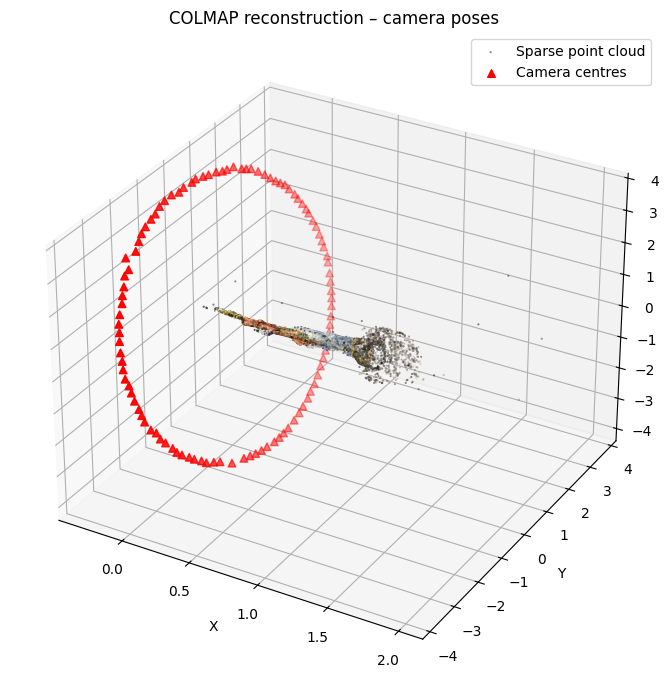


Scene centre : [ 0.00179258 -0.00638008 -0.02248126]
Scene radius : 3.8700


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Build c2w matrices and camera centres
c2w_mats = {}
for img_id, info in images_dict.items():
    c2w_mats[img_id] = colmap_to_c2w(info["qvec"], info["tvec"])

cam_centers = np.stack([m[:3, 3] for m in c2w_mats.values()])
scene_center = cam_centers.mean(axis=0)
scene_scale  = np.linalg.norm(cam_centers - scene_center, axis=-1).max()

# Plot camera positions + sparse point cloud
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")

if points_dict:
    rng = np.random.default_rng(0)
    pts = np.stack([v["xyz"] for v in points_dict.values()])
    cols = np.stack([v["rgb"] for v in points_dict.values()]) / 255.0
    # Subsample for display
    idx = rng.choice(len(pts), min(8_000, len(pts)), replace=False)
    ax.scatter(pts[idx, 0], pts[idx, 1], pts[idx, 2],
               c=cols[idx], s=0.3, alpha=0.5, label="Sparse point cloud")

ax.scatter(cam_centers[:, 0], cam_centers[:, 1], cam_centers[:, 2],
           c="red", s=30, marker="^", zorder=5, label="Camera centres")
ax.set_title("COLMAP reconstruction – camera poses")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nScene centre : {scene_center}")
print(f"Scene radius : {scene_scale:.4f}")

## 4. Build NeRF Dataset

Loads all training images and pre-computes every ray.  This step also normalises
the scene so that camera origins lie approximately on the unit sphere and computes
near/far planes from the sparse 3-D point cloud.

In [6]:
dataset = ColmapNeRFDataset(
    colmap_dir   = COLMAP_DIR,
    image_dir    = IMAGE_DIR,
    scale_factor = SCALE_FACTOR,
    white_bg     = WHITE_BG,
    device       = DEVICE,
)

NEAR = dataset.near
FAR  = dataset.far
H    = dataset.H
W    = dataset.W

# ── Train / val split – hold out every 8th image for validation ──────────────
val_indices   = list(range(0, dataset.N, 8))
train_indices = [i for i in range(dataset.N) if i not in val_indices]
if len(val_indices) == 0:
    val_indices = [0]

# Build training rays (exclude validation images)
train_rays_o  = torch.cat([dataset.rays_o[i*H*W:(i+1)*H*W] for i in train_indices])
train_rays_d  = torch.cat([dataset.rays_d[i*H*W:(i+1)*H*W] for i in train_indices])
train_targets = torch.cat([dataset.targets[i*H*W:(i+1)*H*W] for i in train_indices])

print(f"\nTraining images  : {len(train_indices)}")
print(f"Validation images: {len(val_indices)}")
print(f"Total training rays: {train_rays_o.shape[0]:,}")

[ColmapNeRFDataset] 103 images (480×270)  near=0.855  far=1.164  scene_scale=3.8700

Training images  : 90
Validation images: 13
Total training rays: 11,664,000


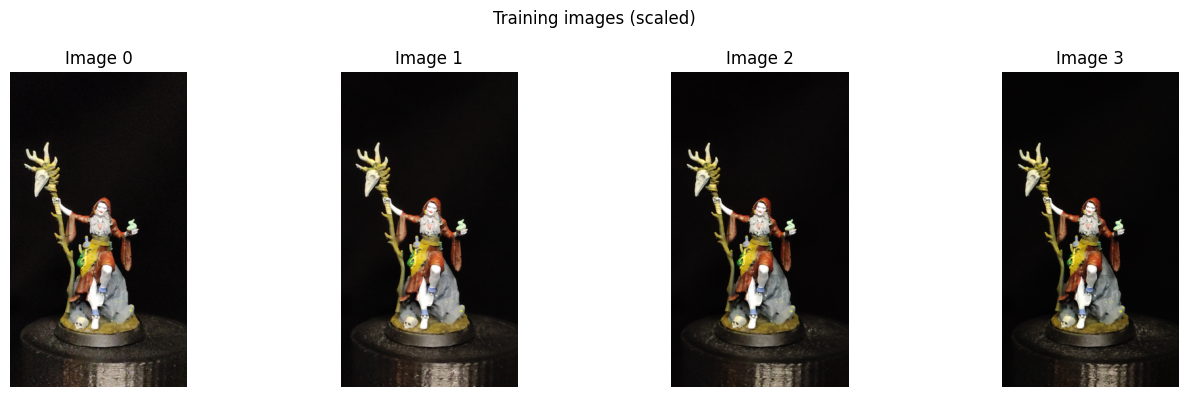

In [6]:
# Quick sanity-check: visualise one training image
fig, axes = plt.subplots(1, min(4, dataset.N), figsize=(14, 4))
if dataset.N == 1:
    axes = [axes]
for ax, idx in zip(axes, range(min(4, dataset.N))):
    ax.imshow(dataset.images[idx].cpu().numpy().clip(0, 1))
    ax.set_title(f"Image {idx}")
    ax.axis("off")
plt.suptitle("Training images (scaled)")
plt.tight_layout()
plt.show()

## 5. Initialise Model & Optimiser

The standard NeRF pipeline uses **positional encoding** ($\gamma$) to map low-dimensional
inputs into a higher-dimensional space before feeding them to the MLP:

$$\gamma(p) = \bigl[\sin(2^0 \pi p),\;\cos(2^0 \pi p),\;\dots,\;\sin(2^{L-1} \pi p),\;\cos(2^{L-1} \pi p)\bigr]$$

- **Position** encoding: $L=10$ → 63-dim input
- **View direction** encoding: $L=4$ → 27-dim input

Two networks are used:
- **Coarse** – queries from stratified samples
- **Fine** – queries from hierarchical importance samples


In [7]:
# ── Positional encoding ───────────────────────────────────────────────────────
embed_fn, input_ch = get_embedder(MULTIRES)
embeddirs_fn, input_ch_views = get_embedder(MULTIRES_VIEWS)

print(f"Position encoding dim  : {input_ch}")
print(f"View-dir encoding dim  : {input_ch_views}")

# ── Coarse model ──────────────────────────────────────────────────────────────
""" model_coarse = NeRF(
    D=8, W=256,
    input_ch=input_ch,
    input_ch_views=input_ch_views,
    use_viewdirs=USE_VIEWDIRS,
).to(DEVICE)

# ── Fine model (same architecture) ───────────────────────────────────────────
model_fine = None
if USE_FINE and N_FINE > 0:
    model_fine = NeRF(
        D=8, W=256,
        input_ch=input_ch,
        input_ch_views=input_ch_views,
        use_viewdirs=USE_VIEWDIRS,
    ).to(DEVICE) """

model_coarse, embed_fn, embeddirs_fn = get_instant_ngp(use_viewdirs=USE_VIEWDIRS)
model_coarse.to(DEVICE)
model_fine, _, _ = get_instant_ngp(use_viewdirs=USE_VIEWDIRS)  # optional
model_fine.to(DEVICE)

""" model_coarse, embed_fn, embeddirs_fn = get_fast_nerf(use_viewdirs=USE_VIEWDIRS)
model_coarse.to(DEVICE)
model_fine, _, _ = get_fast_nerf(use_viewdirs=USE_VIEWDIRS)  # optional
model_fine.to(DEVICE) """

# Quick summary — InstantNGP takes raw [xyz | viewdirs] = 6 dims
sample_input = torch.randn(4, 6).to(DEVICE)
summary(model_coarse, input_data=sample_input,
        col_names=["input_size", "output_size", "num_params"], depth=3)

# ── Optimiser + LR schedule ───────────────────────────────────────────────────
# Original NeRF: lr decays exponentially from lr_init to lr_init * lr_decay_rate^(N/decay_steps)
# We scale proportionally: LR decays by LR_DECAY (×0.1) continuously over all N_ITERS.
params = list(model_coarse.parameters())
if model_fine is not None:
    params += list(model_fine.parameters())
    print(f"\nFine model parameters: {sum(p.numel() for p in model_fine.parameters()):,}")

optimizer = torch.optim.Adam(params, lr=LR, betas=(0.9, 0.999))

# Exponential LR decay: LR_final = LR * LR_DECAY  (same semantic as the original NeRF paper)
lr_lambda = lambda step: LR_DECAY ** (step / N_ITERS)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f"LR schedule: {LR:.1e} → {LR * LR_DECAY:.1e}  (exponential over {N_ITERS:,} steps)")
print("Models & optimiser ready.")

Position encoding dim  : 63
View-dir encoding dim  : 27

Fine model parameters: 16,788,932
LR schedule: 5.0e-04 → 5.0e-05  (exponential over 50,000 steps)
Models & optimiser ready.


## 6. Training Loop

Each step:
1. Sample `BATCH_SIZE` random rays from all training images (via `ColmapNeRFDataset`)
2. Stratified sample `N_COARSE` points along each ray
3. Run `render_rays` → MSE loss against ground-truth pixel colours
4. Back-propagate and update weights

PSNR (Peak Signal-to-Noise Ratio) is logged as a quality metric:
$$\text{PSNR} = -10 \log_{10}(\text{MSE})$$


Training:   0%|          | 0/50000 [00:00<?, ?it/s]

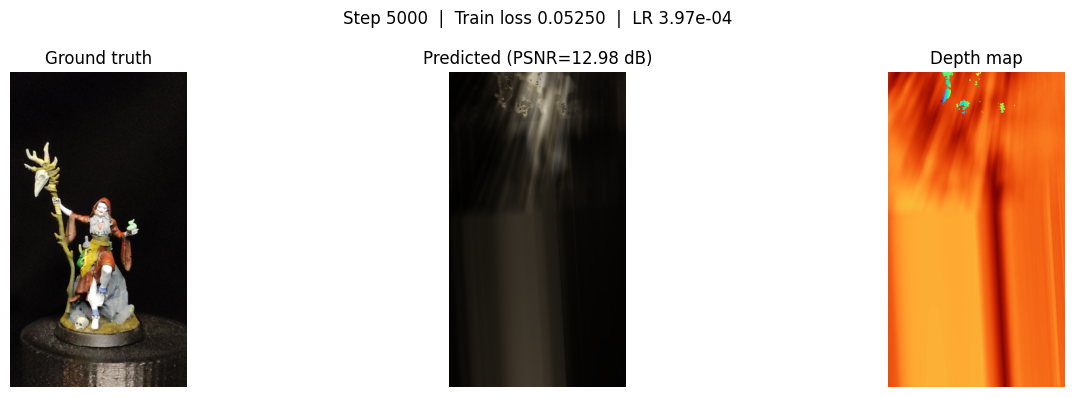

  Saved best model (PSNR=12.98 dB)


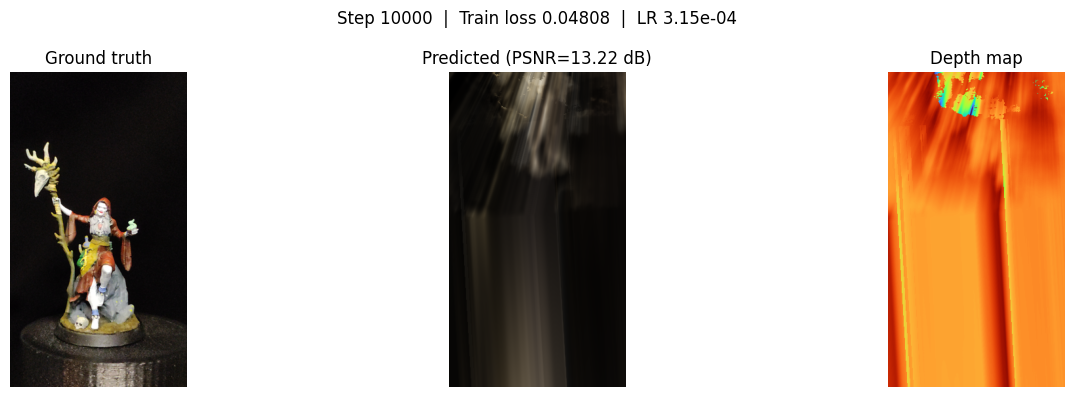

  Saved best model (PSNR=13.22 dB)


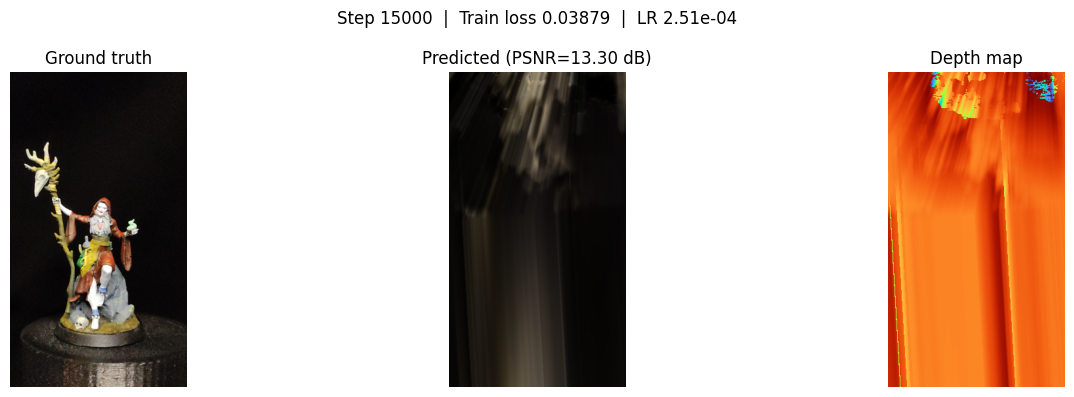

  Saved best model (PSNR=13.30 dB)


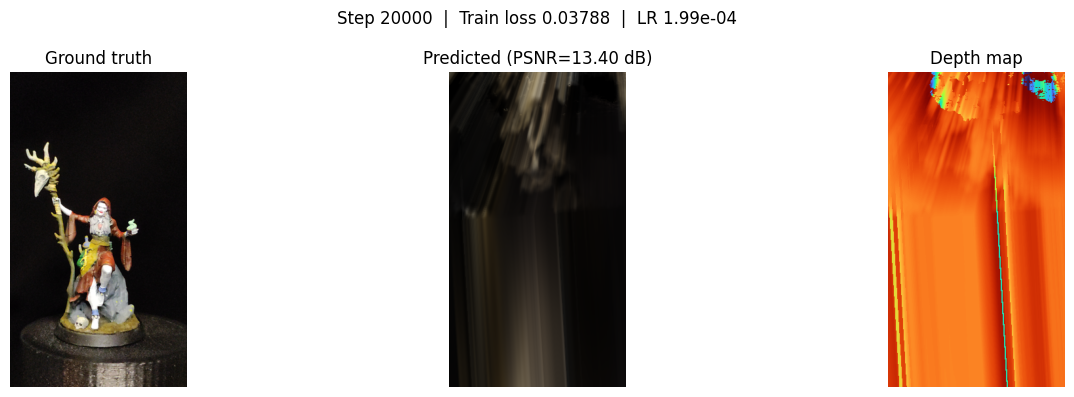

  Saved best model (PSNR=13.40 dB)


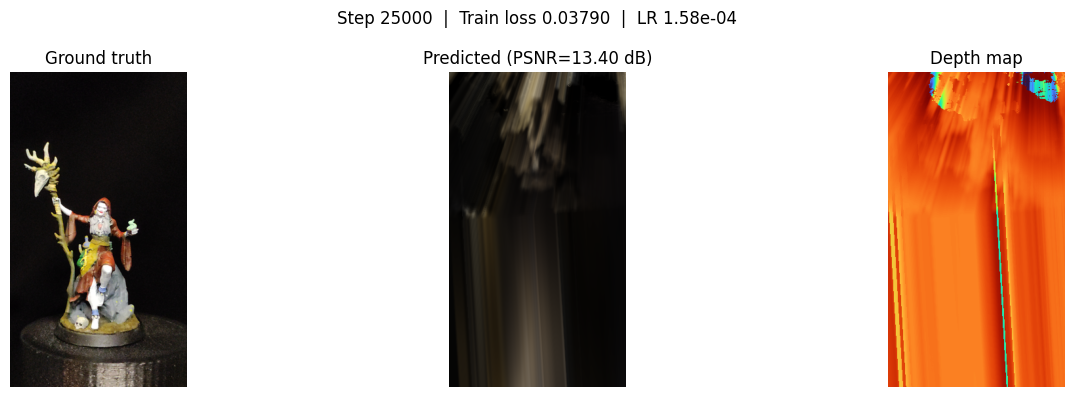

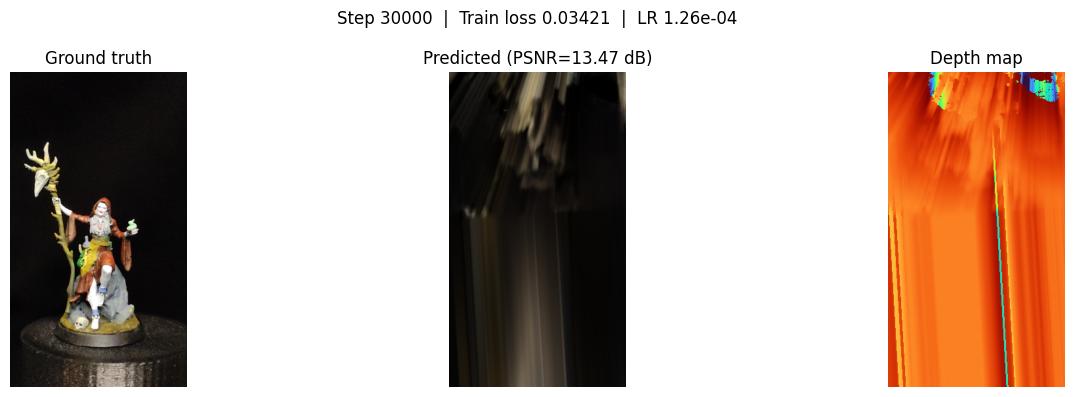

  Saved best model (PSNR=13.47 dB)


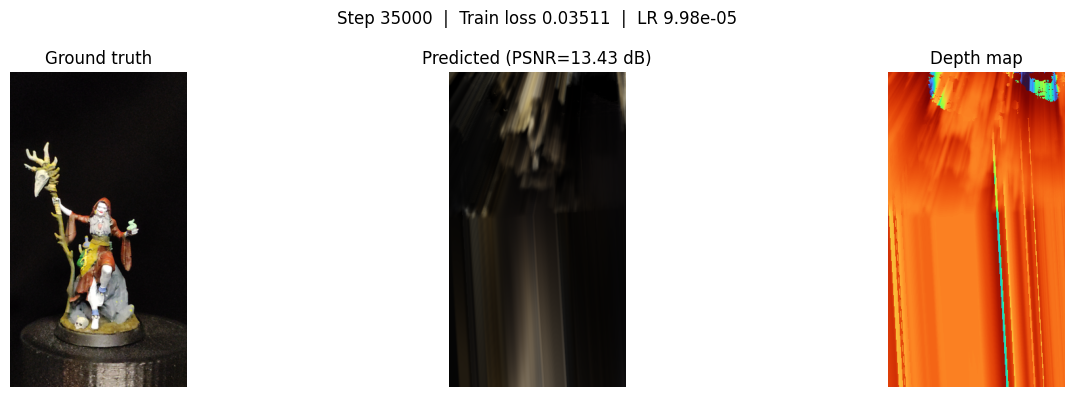

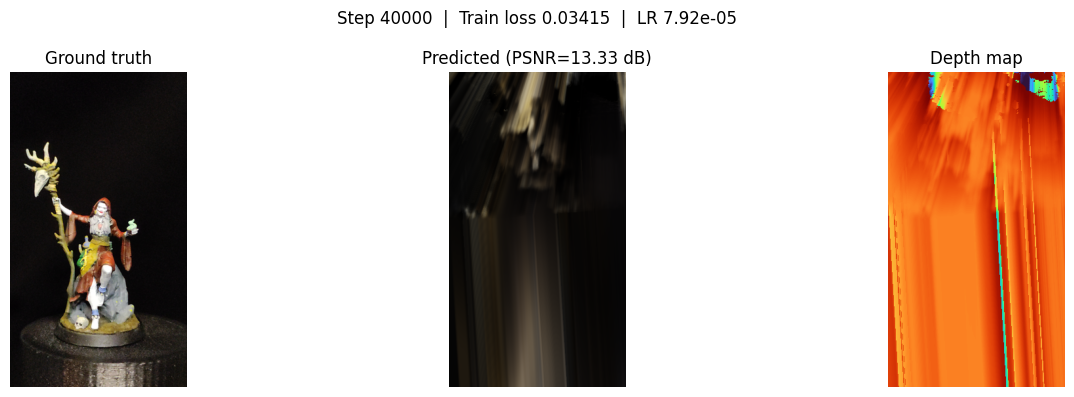

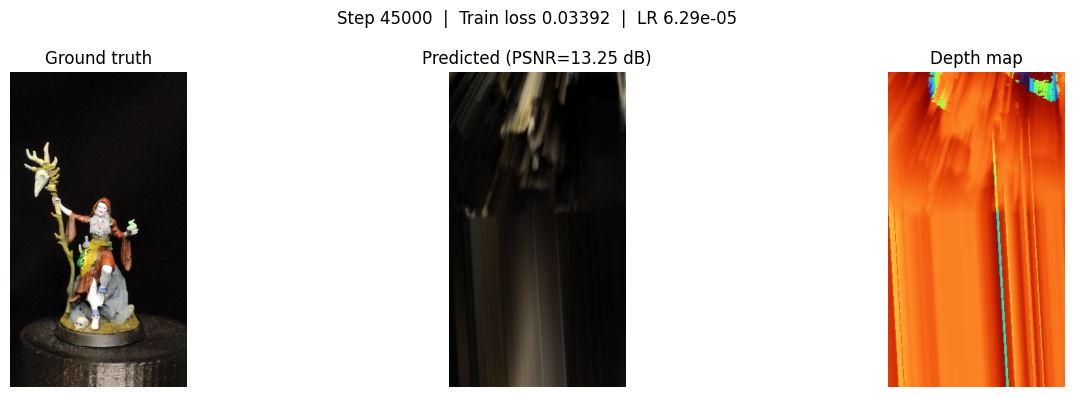

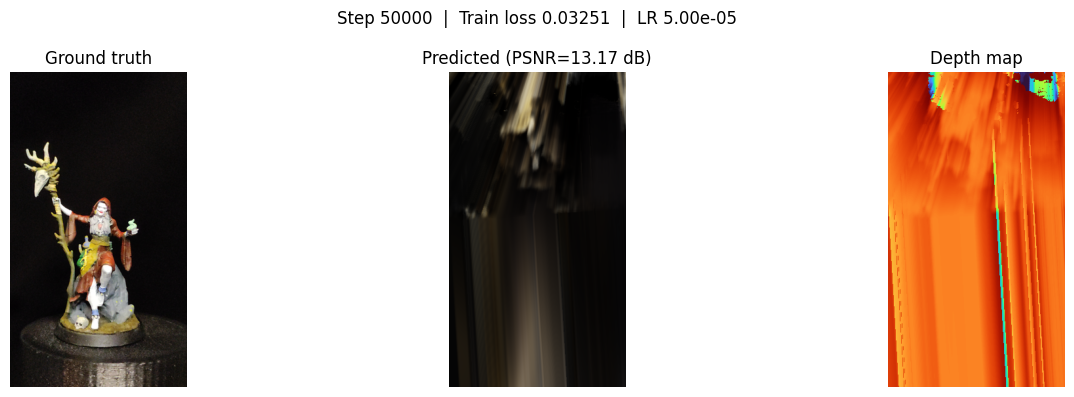


Training complete in 249.5 min  |  Best val PSNR: 13.47 dB


In [8]:
# ── Helper: render a full image in chunks ─────────────────────────────────────
@torch.no_grad()
def render_full_image(model_c, model_f, c2w, K, H, W, near, far,
                       N_samples, N_importance, embed_fn, embeddirs_fn,
                       chunk=RENDER_CHUNK, white_bkgd=WHITE_BG):
    """Render a complete (H, W) image by chunking over rays."""
    rays_o, rays_d = get_rays(H, W, K, c2w)
    rays_o_flat = rays_o.reshape(-1, 3)
    rays_d_flat = rays_d.reshape(-1, 3)

    all_rgb, all_depth, all_acc = [], [], []
    for i in range(0, rays_o_flat.shape[0], chunk):
        ret = render_rays(
            model_c, rays_o_flat[i:i+chunk], rays_d_flat[i:i+chunk],
            near, far, N_samples,
            N_importance=N_importance, model_fine=model_f,
            embed_fn=embed_fn, embeddirs_fn=embeddirs_fn,
            rand=False, white_bkgd=white_bkgd,
            raw_noise_std=0.0,   # no noise during inference
        )
        all_rgb.append(ret['rgb_map'])
        all_depth.append(ret['depth_map'])
        all_acc.append(ret['acc_map'])

    rgb   = torch.cat(all_rgb).reshape(H, W, 3)
    depth = torch.cat(all_depth).reshape(H, W)
    acc   = torch.cat(all_acc).reshape(H, W)
    return rgb, depth, acc


# ── Training ──────────────────────────────────────────────────────────────────
best_psnr = 0.0
save_path = os.path.join(OUTPUT_DIR, 'best_nerf.pth')
train_losses, train_psnrs = [], []
val_psnrs = []

N_train_rays = train_rays_o.shape[0]
t0 = time.time()

pbar = trange(1, N_ITERS + 1, desc="Training", dynamic_ncols=True)
for step in pbar:
    model_coarse.train()
    if model_fine is not None:
        model_fine.train()

    # Sample a random batch of rays from training set
    idx = torch.randint(0, N_train_rays, (BATCH_SIZE,), device=DEVICE)
    rays_o = train_rays_o[idx]
    rays_d = train_rays_d[idx]
    target = train_targets[idx]

    ret = render_rays(
        model_coarse, rays_o, rays_d, NEAR, FAR, N_COARSE,
        N_importance=N_FINE, model_fine=model_fine,
        embed_fn=embed_fn, embeddirs_fn=embeddirs_fn,
        rand=True, white_bkgd=WHITE_BG,
        raw_noise_std=1.0,   # original NeRF: noise regularises density during training
    )

    # Fine (or coarse-only) MSE + coarse auxiliary loss (original NeRF §5.3)
    loss = F.mse_loss(ret['rgb_map'], target)
    if 'rgb_map_coarse' in ret:
        loss = loss + F.mse_loss(ret['rgb_map_coarse'], target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    psnr = -10.0 * torch.log10(F.mse_loss(ret['rgb_map'].detach(), target)).item()
    pbar.set_postfix(loss=f"{loss.item():.4f}", psnr=f"{psnr:.2f}",
                     lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    if step % LOG_EVERY == 0:
        train_losses.append(loss.item())
        train_psnrs.append(psnr)

    # ── Periodic validation render ────────────────────────────────────────
    if step % RENDER_EVERY == 0:
        model_coarse.eval()
        if model_fine is not None:
            model_fine.eval()

        vi = val_indices[0]
        gt_img = dataset.images[vi].cpu().numpy()

        rgb, depth, acc = render_full_image(
            model_coarse, model_fine,
            dataset.c2w[vi], dataset.K[vi], H, W, NEAR, FAR,
            N_COARSE, N_FINE, embed_fn, embeddirs_fn,
        )
        rgb_np   = rgb.clamp(0, 1).cpu().numpy()
        depth_np = depth.cpu().numpy()

        val_psnr = -10.0 * np.log10(((rgb_np - gt_img) ** 2).mean() + 1e-8)
        val_psnrs.append(val_psnr)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].imshow(gt_img.clip(0, 1))
        axes[0].set_title("Ground truth")
        axes[1].imshow(rgb_np)
        axes[1].set_title(f"Predicted (PSNR={val_psnr:.2f} dB)")
        axes[2].imshow(depth_np, cmap="turbo")
        axes[2].set_title("Depth map")
        for ax in axes:
            ax.axis("off")
        plt.suptitle(f"Step {step}  |  Train loss {loss.item():.5f}  |  LR {optimizer.param_groups[0]['lr']:.2e}")
        plt.tight_layout()
        plt.show()

        if val_psnr > best_psnr:
            best_psnr = val_psnr
            ckpt = {
                'step': step,
                'model_coarse': model_coarse.state_dict(),
                'model_fine': model_fine.state_dict() if model_fine else None,
                'optimizer': optimizer.state_dict(),
                'psnr': best_psnr,
            }
            torch.save(ckpt, save_path)
            print(f"  Saved best model (PSNR={best_psnr:.2f} dB)")

elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed/60:.1f} min  |  Best val PSNR: {best_psnr:.2f} dB")

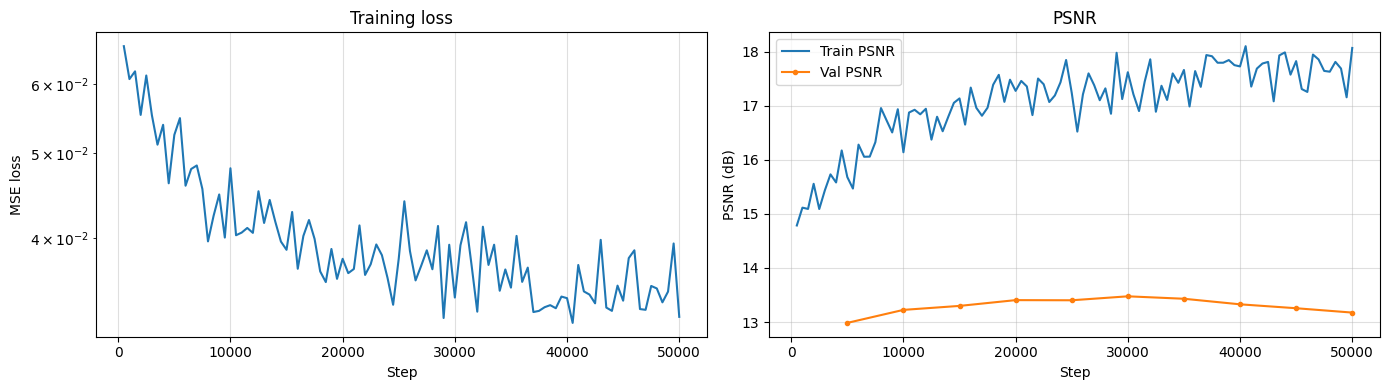

In [9]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

steps_logged = np.arange(1, len(train_losses) + 1) * LOG_EVERY
ax1.plot(steps_logged, train_losses)
ax1.set_xlabel("Step"); ax1.set_ylabel("MSE loss")
ax1.set_title("Training loss"); ax1.set_yscale("log"); ax1.grid(True, alpha=0.4)

ax2.plot(steps_logged, train_psnrs, label="Train PSNR")
if val_psnrs:
    val_steps = np.arange(1, len(val_psnrs) + 1) * RENDER_EVERY
    ax2.plot(val_steps, val_psnrs, label="Val PSNR", marker='o', markersize=3)
ax2.set_xlabel("Step"); ax2.set_ylabel("PSNR (dB)")
ax2.set_title("PSNR"); ax2.legend(); ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 7.  Synthesise a Novel-View Flyaround

Render all training views (for comparison with ground truth) plus optionally synthesise
novel views by interpolating camera poses.

In [ ]:
print("Rendering 360 flyaround ...")
model_coarse.eval()
if model_fine is not None:
    model_fine.eval()

frames_rgb   = []
frames_depth = []
n_frames = 120
phi      = -30.0
radius   = 1.2   # scene is normalised so cameras sit near radius ≈ 1

for th in tqdm(np.linspace(0., 360., n_frames, endpoint=False)):
    c2w = pose_spherical(th, phi, radius).to(DEVICE)
    rgb, depth, acc = render_full_image(
        model_coarse, model_fine,
        c2w, dataset.K[0], H, W, NEAR, FAR,
        N_COARSE, N_FINE, embed_fn, embeddirs_fn,
    )
    rgb_np = (255 * rgb.clamp(0, 1).cpu().numpy()).astype(np.uint8)

    # Normalise depth to [0, 1] and apply colourmap
    depth_np = depth.cpu().numpy()
    d_min, d_max = depth_np.min(), depth_np.max()
    if d_max - d_min > 1e-6:
        depth_norm = (depth_np - d_min) / (d_max - d_min)
    else:
        depth_norm = np.zeros_like(depth_np)
    depth_rgb = (plt.cm.turbo(depth_norm)[..., :3] * 255).astype(np.uint8)

    frames_rgb.append(rgb_np)
    frames_depth.append(depth_rgb)

# Save videos
rgb_video   = os.path.join(OUTPUT_DIR, "nerf_360_rgb.mp4")
depth_video = os.path.join(OUTPUT_DIR, "nerf_360_depth.mp4")
imageio.mimwrite(rgb_video,   frames_rgb)
imageio.mimwrite(depth_video, frames_depth)
print(f"RGB video   -> {rgb_video}")
print(f"Depth video -> {depth_video}")

Rendering 360 flyaround ...


  0%|          | 0/120 [00:00<?, ?it/s]

TypeError: TiffWriter.write() got an unexpected keyword argument 'fps'

## 8. Extract & Save Mesh

Query the NeRF density field on a regular 3-D grid, then run **marching cubes**
to extract an iso-surface and colour each vertex by querying the fine model's RGB.
The result is saved as a `.ply` file that can be opened in MeshLab, Blender, etc.

> **Tip:** Increase `MESH_RESOLUTION` for a finer mesh (memory doubles with each +64).
> A good `SIGMA_THRESHOLD` depends on the scene; try values between 5 and 50.

In [ ]:
import torch.nn.functional as F
from skimage import measure as sk_measure  # scikit-image marching cubes

# ── Mesh extraction settings ─────────────────────────────────────────────────
MESH_RESOLUTION  = 128       # voxels per side (128³ grid)
# SIGMA_THRESHOLD = None → auto-select via percentile (recommended).
# Set to a float to override; it is clamped to the actual data range.
SIGMA_THRESHOLD  = None
SIGMA_PERCENTILE = 97        # top-%tile used when SIGMA_THRESHOLD is None
MESH_QUERY_CHUNK = 65536
MESH_OUT_PATH    = str(Path(OUTPUT_DIR) / "nerf_mesh.ply")

BBOX_MIN = -1.5
BBOX_MAX =  1.5

# Use fine model if available, else coarse
mesh_model = model_fine if model_fine is not None else model_coarse
mesh_model.eval()

print(f"Building {MESH_RESOLUTION}³ density grid …")
lin = torch.linspace(BBOX_MIN, BBOX_MAX, MESH_RESOLUTION, device=DEVICE)
grid_x, grid_y, grid_z = torch.meshgrid(lin, lin, lin, indexing="ij")
pts_grid = torch.stack([grid_x, grid_y, grid_z], dim=-1).reshape(-1, 3)

sigma_vals = []
# Arbitrary fixed view direction for density query
dummy_dir = torch.zeros(MESH_QUERY_CHUNK, 3, device=DEVICE)
dummy_dir[..., 2] = -1.0

with torch.no_grad():
    for start in range(0, pts_grid.shape[0], MESH_QUERY_CHUNK):
        chunk_pts = pts_grid[start : start + MESH_QUERY_CHUNK]
        n = chunk_pts.shape[0]

        # Encode points and view directions (embed_fn=None for InstantNGP)
        embedded_pts  = embed_fn(chunk_pts) if embed_fn is not None else chunk_pts
        embedded_dirs = embeddirs_fn(dummy_dir[:n]) if embeddirs_fn is not None else dummy_dir[:n]
        inp = torch.cat([embedded_pts, embedded_dirs], dim=-1)

        raw = mesh_model(inp)
        sigma_vals.append(raw[..., 3].cpu())  # density is the 4th channel

sigma_grid = torch.cat(sigma_vals).reshape(
    MESH_RESOLUTION, MESH_RESOLUTION, MESH_RESOLUTION
).numpy()

# Apply ReLU to density (NeRF uses ReLU activation on raw density in volume rendering)
sigma_grid = np.maximum(sigma_grid, 0)

s_min, s_max = float(sigma_grid.min()), float(sigma_grid.max())
print(f"Density grid: min={s_min:.4f}  max={s_max:.4f}  mean={sigma_grid.mean():.4f}")

# Auto-select or validate threshold
if SIGMA_THRESHOLD is None:
    sigma_threshold = float(np.percentile(sigma_grid, SIGMA_PERCENTILE))
    print(f"Auto threshold (p{SIGMA_PERCENTILE}): {sigma_threshold:.4f}")
else:
    sigma_threshold = float(np.clip(SIGMA_THRESHOLD, s_min + 1e-6, s_max - 1e-6))
    print(f"Using threshold: {sigma_threshold:.4f}  (data range [{s_min:.4f}, {s_max:.4f}])")

print(f"Voxels above threshold: {(sigma_grid > sigma_threshold).sum():,} / {sigma_grid.size:,}")

Building 128³ density grid …
Density grid: min=0.0000  max=0.0281  mean=0.0001
Auto threshold (p97): 0.0007
Voxels above threshold: 62,915 / 2,097,152


Running marching cubes at threshold=0.0007 …
Mesh: 99,814 vertices  |  195,920 triangles
Colouring vertices …
Mesh saved → C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_mesh.ply


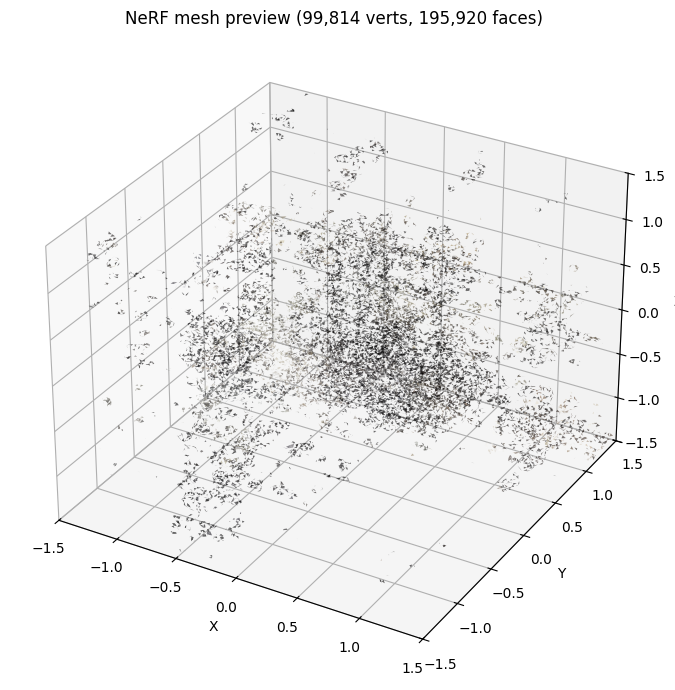

In [ ]:
# ── Marching cubes ───────────────────────────────────────────────────────────
print(f"Running marching cubes at threshold={sigma_threshold:.4f} …")
verts_idx, faces, normals, _ = sk_measure.marching_cubes(
    sigma_grid, level=sigma_threshold, allow_degenerate=False
)

# Convert voxel indices → world coordinates (normalised scene space)
verts_world = verts_idx / (MESH_RESOLUTION - 1) * (BBOX_MAX - BBOX_MIN) + BBOX_MIN

print(f"Mesh: {len(verts_world):,} vertices  |  {len(faces):,} triangles")

# ── Colour vertices by querying the model ──────────────────────────────────
print("Colouring vertices …")
mesh_model.eval()
verts_t   = torch.from_numpy(verts_world.astype(np.float32)).to(DEVICE)
view_dirs = F.normalize(-verts_t, dim=-1)
vert_rgb  = []

with torch.no_grad():
    for start in range(0, verts_t.shape[0], MESH_QUERY_CHUNK):
        v_chunk = verts_t[start : start + MESH_QUERY_CHUNK]
        d_chunk = view_dirs[start : start + MESH_QUERY_CHUNK]

        embedded_pts  = embed_fn(v_chunk) if embed_fn is not None else v_chunk
        embedded_dirs = embeddirs_fn(d_chunk) if embeddirs_fn is not None else d_chunk
        inp = torch.cat([embedded_pts, embedded_dirs], dim=-1)
        raw = mesh_model(inp)

        rgb = torch.sigmoid(raw[..., :3])  # apply sigmoid like in raw2outputs
        vert_rgb.append(rgb.cpu())

vert_rgb_np = torch.cat(vert_rgb).numpy()   # (V, 3)  float in [0, 1]
vert_rgb_u8 = (vert_rgb_np * 255).clip(0, 255).astype(np.uint8)

# ── Write PLY ────────────────────────────────────────────────────────────────
def _write_ply(path: str, verts: np.ndarray, faces: np.ndarray,
               colors: np.ndarray) -> None:
    """Write a coloured triangle mesh as a binary PLY file."""
    n_verts = len(verts)
    n_faces = len(faces)
    header = (
        "ply\n"
        "format binary_little_endian 1.0\n"
        f"element vertex {n_verts}\n"
        "property float x\nproperty float y\nproperty float z\n"
        "property uchar red\nproperty uchar green\nproperty uchar blue\n"
        f"element face {n_faces}\n"
        "property list uchar int vertex_indices\n"
        "end_header\n"
    )
    import struct
    with open(path, "wb") as f:
        f.write(header.encode("ascii"))
        for (x, y, z), (r, g, b) in zip(verts.astype(np.float32), colors):
            f.write(struct.pack("<fff", x, y, z))
            f.write(struct.pack("BBB", r, g, b))
        for tri in faces.astype(np.int32):
            f.write(struct.pack("<B", 3))
            f.write(struct.pack("<iii", tri[0], tri[1], tri[2]))

_write_ply(MESH_OUT_PATH, verts_world, faces, vert_rgb_u8)
print(f"Mesh saved → {MESH_OUT_PATH}")

# ── Quick preview ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection="3d")
# Sample a subset of faces for display performance
rng  = np.random.default_rng(42)
idx  = rng.choice(len(faces), min(20_000, len(faces)), replace=False)
tri  = verts_world[faces[idx]]   # (S, 3, 3)
cols = vert_rgb_np[faces[idx]].mean(axis=1)  # (S, 3) face colour

from mpl_toolkits.mplot3d.art3d import Poly3DCollection
poly = Poly3DCollection(tri, alpha=0.6, linewidth=0)
poly.set_facecolor(cols.clip(0, 1))
ax.add_collection3d(poly)

v = verts_world
ax.set_xlim(v[:, 0].min(), v[:, 0].max())
ax.set_ylim(v[:, 1].min(), v[:, 1].max())
ax.set_zlim(v[:, 2].min(), v[:, 2].max())
ax.set_title(f"NeRF mesh preview ({len(verts_world):,} verts, {len(faces):,} faces)")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
plt.tight_layout()
plt.savefig(str(Path(OUTPUT_DIR) / "mesh_preview.png"), dpi=120)
plt.show()